# Training QGAN to generate dp distributions for a range of mc_p

### Data preprocessing

In [1]:
from qgan_lamarr.load_dp import load_dp
import matplotlib.pyplot as plt

num_qubits = 5
nbins = 2**num_qubits

2026-05-07 23:18:37.320737: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 23:18:37.953161: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778188718.156490    4941 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778188718.210038    4941 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778188718.753943    4941 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
dp1 = load_dp((20000, 21000), 'mu')
dp2 = load_dp((10000, 11000), 'mu')

Found 1 files
['/home/fredo/qgan-lamarr/LamarrTraining.root']
Data loaded
Found 1 files
['/home/fredo/qgan-lamarr/LamarrTraining.root']
Data loaded


In [4]:
dp2 = load_dp((10000, 11000), 'mu')

Found 1 files
['/home/fredo/qgan-lamarr/LamarrTraining.root']
Data loaded


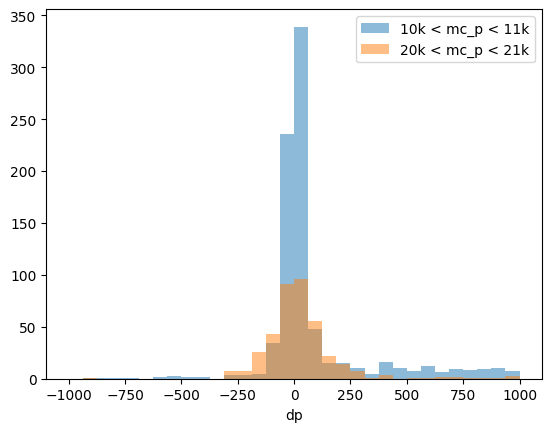

In [9]:
dpr1 = dp1.loc[lambda x : (x <= 1000) & (x >= -1000)]
dpr2 = dp2.loc[lambda x : (x <= 1000) & (x >= -1000)]
plt.hist(dpr2, bins = nbins, range = (-1000, 1000), alpha = 0.5, label = '10k < mc_p < 11k')
plt.hist(dpr1, bins = nbins, range = (-1000, 1000), alpha = 0.5, label = '20k < mc_p < 21k')
plt.xlabel('dp')
plt.legend()
plt.show()

In [4]:
def norm_binning(_data, _nbins):
    
    data_interval = max(_data) - min(_data)
    bin_length = float(data_interval)/float(_nbins)
    
    binned_data = {}
    for b in range(_nbins):
        bin_min_val = min(_data) + bin_length * b
        bin_max_val = min(_data) + bin_length * (b+1)
        
        bin_counts = sum(1 for x in _data if bin_min_val <= x < bin_max_val)
        if b == _nbins-1: 
            bin_counts += sum(1 for x in _data if x == bin_max_val)

        binned_data.update({format(int(b), f'0{int(np.log2(_nbins))}b') : bin_counts})
    return binned_data

def sample_dist(_size, _nbins):
    _sample = np.random.choice(dpr, size = _size, replace=True)
    return norm_binning(_sample, _nbins)

In [5]:
len(dpr)

193

### Generator

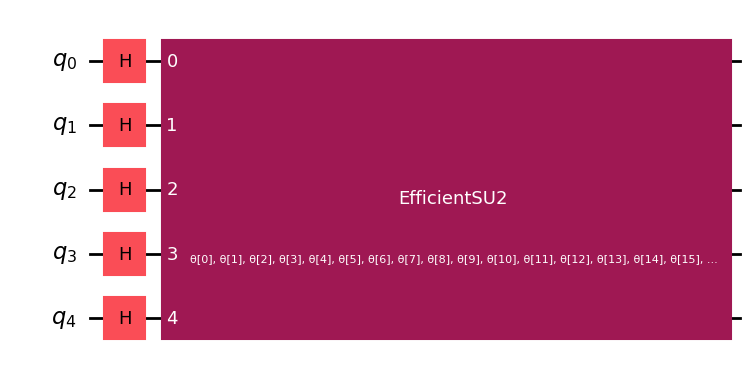

In [14]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import efficient_su2
qc = QuantumCircuit(num_qubits)
qc.h(range(num_qubits))
esu2_gate = efficient_su2(num_qubits = num_qubits, su2_gates=['rx', 'ry'], reps = 7).to_gate()
qc.append(esu2_gate, range(num_qubits))
qc.draw('mpl')

### Discriminator

In [15]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, InputLayer

discriminator = Sequential([InputLayer(input_shape=(nbins,)),
                            Dense(2**7, activation='tanh', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.L2(1e-3)),
                            Dense(2**7, activation='tanh', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.L2(1e-3)),
                            Dense(1, activation='sigmoid')
                            ])
discriminator.summary()

/usr/local/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,865 (81.50 KB)

 Trainable params: 20,865 (81.50 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from qgan import QGAN
model = QGAN(num_qubits = num_qubits,
             generator = qc,
             discriminator = discriminator,
             real_dist = sample_dist)

In [17]:
epochs = 3000
model.fit(epochs = epochs)

100%|█████████████████████████████████████████████████████████████████████████████| 3000/3000 [4:20:13<00:00,  5.20s/it]


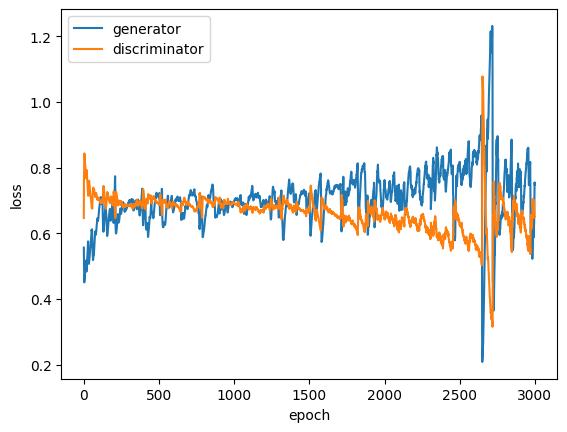

In [18]:
plt.plot(range(epochs), model.generator_losses, label = 'generator')
plt.plot(range(epochs), model.discriminator_losses, label = 'discriminator')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

In [19]:
nsamples = 2**14
gen_res = model.get_sample(nsamples)
real_res = sample_dist(nsamples, nbins)
print(f'KS score: {model.scoreKS(nsamples)}')
print(f'KS 0.1: {1.22/(nsamples)**(0.5)}')
print(f'KS 0.05: {1.36/(nsamples)**(0.5)}')
print(f'KS 0.01: {1.63/(nsamples)**(0.5)}')

KS score: 28.359375
KS 0.1: 0.00953125
KS 0.05: 0.010625
KS 0.01: 0.012734375


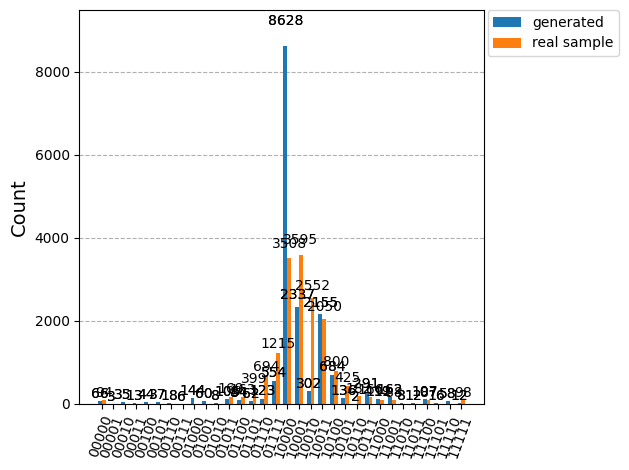

In [20]:
from qiskit.visualization import plot_histogram
plot_histogram([gen_res, real_res], legend = ["generated","real sample"])

In [21]:
sum(gen_res.values())

16384

In [22]:
sum(real_res.values())

16384